# Metadata, Source-Link, and Storage Tradeoff Worksheet

This is your Module 2 project artifact. It builds on the vector schema you drafted in
Module 1. Complete all three sections, then verify them with `validate-worksheet.py`.

---

## 1. Metadata Dictionary and Field Classification

Document every field. **Classification** is one of: `stored-only`, `filterable`,
`displayable`, `audit-oriented`. **Filter role** is one of: `none`, `relevance`,
`governance`. The non-governance rows are filled in for you — complete the four
**Governance & access control** rows to match what you set in `metadata-dictionary.json`.

| Field | Type | Classification | Filter role | Purpose |
| ----- | ---- | -------------- | ----------- | ------- |
| `vector_id` | str | stored-only | none | Unique id for the embedded chunk |
| `embedding` | list[float] | stored-only | none | The vector itself |
| `embedding_model` | str | stored-only | none | Model + version (reproducibility) |
| `text` | str | displayable | none | Chunk text shown to the user |
| `source_document_id` | str | stored-only | none | Links the vector to its source document |
| `chunk_id` | str | stored-only | none | Identifies the chunk within the document |
| `source_uri` | str | displayable | none | Source location, shown as a citation |
| `content_version` | str | audit-oriented | none | Source version for consistency checks |
| `content_type` | str | filterable | relevance | Filter by document type |
| `topic` | str | filterable | relevance | Filter by subject |
| `product` | str \| None | filterable | relevance | Filter by product |
| `region` | str | filterable | relevance | Filter by region / data residency |
| `language` | str | filterable | relevance | Filter by language |
| `tenant_id` | str | filterable | governance | Isolates one tenant's data from another's |
| `access_group` | str | filterable | governance | Records accountability for the source; not used to filter |
| `sensitivity_label` | str | filterable | governance | Excludes content above a caller's clearance |
| `source_owner` | str | audit-oriented | none | Records accountability for the source; not used to filter |
| `created_at` | datetime | audit-oriented | none | When the vector was created |
| `last_validated_at` | datetime \| None | audit-oriented | none | Last consistency check |
| `deleted_at` | datetime \| None | audit-oriented | none | Soft-delete marker |
| `eval_split` | str \| None | stored-only | none | Marks evaluation/test records |

---

## 2. Source-Link Mapping

For each source document, record the authoritative system and the lookup path that connects
a vector back to its source of truth.

| Source document | Authoritative system | Lookup path (source_uri) | Notes |
| --------------- | -------------------- | ------------------------ | ----- |
| doc-003 | TechNova Support CMS (knowledge base) | kb://technova/specs/anx-14 | Product spec; public |
| doc-004 | TechNova Support CMS (knowledge base) | kb://technova/support/battery | Troubleshooting; public |
| doc-006 | TechNova Identity / Account service | kb://technova/account/reset-password | How-to; internal |
| doc-008 | Legal & Compliance document repository | kb://technova/legal/gdpr | Policy; confidential, EU |
| doc-011 | TechNova Support CMS (knowledge base) | kb://technova/specs/rx-450 | Firmware spec; public |


---

## 3. Storage Tradeoff Note (at least 3 decisions)

Explain at least three design decisions in plain engineering language.

1. **Why some metadata is NOT filterable:**
2. **How identifier stability affects refresh/consistency later:**
3. **Why governance metadata must be designed early, not bolted on:**

## **ANSWERS**
1. **Why some metadata is NOT filterable:** Fields like `embedding`, `text`, and `source_owner` add no value as filter predicates and would only enlarge the filter index and slow queries, so they are stored or kept for audit rather than made filterable.
2. **How identifier stability affects refresh/consistency later:** `source_document_id` and `chunk_id` must stay stable across re-embeds; if they change on every refresh, Module 4 cannot match source records to existing vectors to update or delete them, producing stale or orphaned entries.
3. **Why governance metadata must be designed early, not bolted on:** `tenant_id`, `access_group`, and `sensitivity_label` drive access-control filters. Retrofitting them after deployment means re-embedding or backfilling the whole corpus and risks leaking data in the meantime, so they belong in the schema from day one.


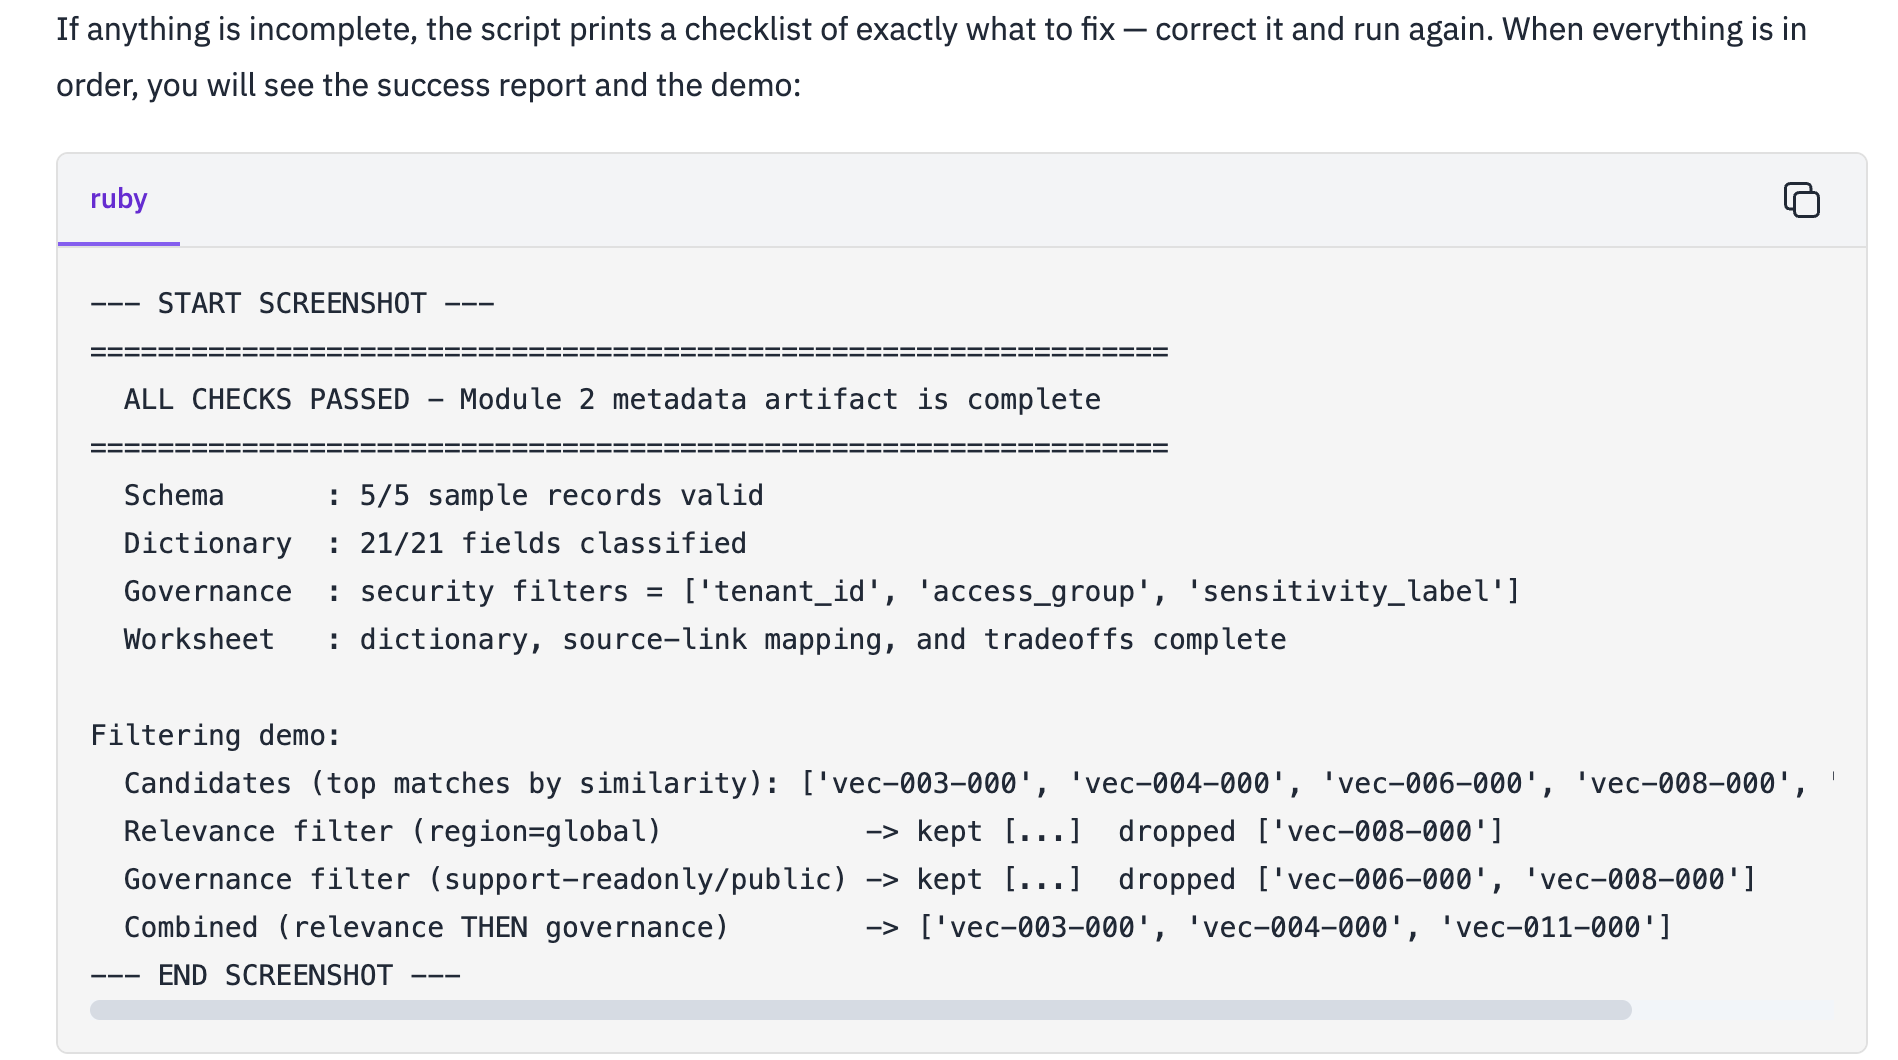